<a href="https://colab.research.google.com/github/kavyasri378/Student_performance_DS/blob/main/Student_performance_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for charts
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Cell 2: Load dataset and check basic information
file_path = 'Student-performance - Student_Performance_Data.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully! Total records: {len(df)}")
except FileNotFoundError:
    print("Error: CSV file not found. Please upload 'Student-performance - Student_Performance_Data.csv' to Google Colab Files.")

# Display data summary & check missing values
print("\n--- Dataset Overview ---")
print(df.info())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

print("\n--- First 5 Rows ---")
df.head()

Dataset loaded successfully! Total records: 1000

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               1000 non-null   object 
 1   Gender                   1000 non-null   object 
 2   Course                   1000 non-null   object 
 3   Attendance_Percentage    1000 non-null   float64
 4   Internal_Marks           1000 non-null   int64  
 5   Assignment_Submissions   1000 non-null   int64  
 6   Platform_Hours_Per_Week  1000 non-null   float64
 7   Resource_Access_Count    1000 non-null   int64  
 8   Engagement_Trend         1000 non-null   object 
 9   Previous_GPA             1000 non-null   float64
 10  Overall_Score            1000 non-null   float64
 11  Performance_Status       1000 non-null   object 
 12  Pass_Fail                1000 non-null   object 
 13  At_R

,Student_ID,Gender,Course,Attendance_Percentage,Internal_Marks,Assignment_Submissions,Platform_Hours_Per_Week,Resource_Access_Count,Engagement_Trend,Previous_GPA,Overall_Score,Performance_Status,Pass_Fail,At_Risk_Flag,Support_Intervention
0,STU-1001,Male,Software Engineering,79.9,79,9,16.5,155,Stable,1.95,67.9,Satisfactory,Pass,Normal,Academic Peer Mentoring
1,STU-1002,Male,Computer Science,81.3,84,9,16.9,164,Improving,2.02,70.7,Good,Pass,Normal,Regular Advising / Honors Track
2,STU-1003,Female,Data Science,82.1,86,9,17.0,167,Improving,2.07,71.9,Good,Pass,Normal,Regular Advising / Honors Track
3,STU-1004,Female,Artificial Intelligence,82.5,87,8,16.7,167,Improving,2.09,70.8,Good,Pass,Normal,Regular Advising / Honors Track
4,STU-1005,Female,Information Systems,82.5,85,8,16.2,164,Improving,2.08,69.8,Satisfactory,Pass,Normal,Academic Peer Mentoring


In [ ]:
# Cell 3: Performance Distributions and Behavioral Analysis

print("=== 1. PERFORMANCE STATUS DISTRIBUTION ===")
print(df['Performance_Status'].value_counts())

print("\n=== 2. ATTENDANCE & MARKS RELATIONSHIP BY PERFORMANCE TIER ===")
perf_summary = df.groupby('Performance_Status')[['Attendance_Percentage', 'Internal_Marks', 'Assignment_Submissions', 'Overall_Score']].mean().round(2)
display(perf_summary)

print("\n=== 3. COMPARE LEARNING BEHAVIOR ACROSS COURSES ===")
course_summary = df.groupby('Course')[['Attendance_Percentage', 'Platform_Hours_Per_Week', 'Overall_Score']].mean().round(2)
display(course_summary)

print("\n=== 4. STUDENTS WITH DECLINING ENGAGEMENT ===")
declining_students = df[df['Engagement_Trend'] == 'Declining']
print(f"Total Students with Declining Engagement: {len(declining_students)}")
print("Sample Declining Engagement Students At-Risk:")
display(declining_students[['Student_ID', 'Course', 'Attendance_Percentage', 'Internal_Marks', 'Assignment_Submissions', 'At_Risk_Flag', 'Support_Intervention']].head())

=== 1. PERFORMANCE STATUS DISTRIBUTION ===
Performance_Status
Satisfactory       351
Underperforming    311
Good               258
Excellent           80
Name: count, dtype: int64

=== 2. ATTENDANCE & MARKS RELATIONSHIP BY PERFORMANCE TIER ===


,Attendance_Percentage,Internal_Marks,Assignment_Submissions,Overall_Score
Performance_Status,,,,
Excellent,90.08,95.14,8.85,85.25
Good,80.75,86.54,7.85,75.20
Satisfactory,67.95,75.60,6.66,63.84
Underperforming,52.92,62.34,5.20,50.09



=== 3. COMPARE LEARNING BEHAVIOR ACROSS COURSES ===


,Attendance_Percentage,Platform_Hours_Per_Week,Overall_Score
Course,,,
Artificial Intelligence,68.35,11.63,64.20
Computer Science,68.34,11.64,64.14
Data Science,68.34,11.64,64.21
Information Systems,68.36,11.62,64.28
Software Engineering,68.34,11.64,64.23



=== 4. STUDENTS WITH DECLINING ENGAGEMENT ===
Total Students with Declining Engagement: 384
Sample Declining Engagement Students At-Risk:


,Student_ID,Course,Attendance_Percentage,Internal_Marks,Assignment_Submissions,At_Risk_Flag,Support_Intervention
36,STU-1037,Computer Science,57.4,63,5,At-Risk,Intensive Academic Recovery
37,STU-1038,Data Science,53.7,58,5,At-Risk,Intensive Academic Recovery
38,STU-1039,Artificial Intelligence,50.4,53,5,At-Risk,Intensive Academic Recovery
39,STU-1040,Information Systems,47.6,51,5,At-Risk,Intensive Academic Recovery
40,STU-1041,Software Engineering,45.5,50,6,At-Risk,Intensive Academic Recovery


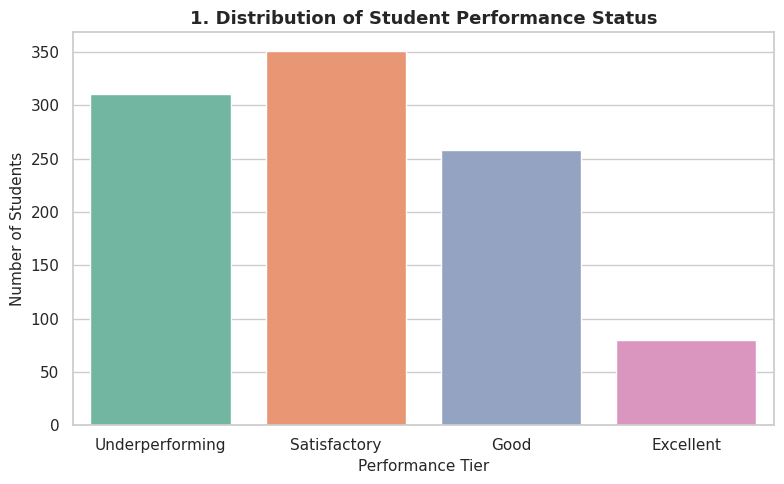

In [ ]:
# Chart 1: Distribution of Student Performance Status
plt.figure(figsize=(8, 5))
order_list = ['Underperforming', 'Satisfactory', 'Good', 'Excellent']

sns.countplot(data=df, x='Performance_Status', order=order_list, palette='Set2')
plt.title('1. Distribution of Student Performance Status', fontsize=13, fontweight='bold')
plt.xlabel('Performance Tier', fontsize=11)
plt.ylabel('Number of Students', fontsize=11)

plt.tight_layout()
plt.show()

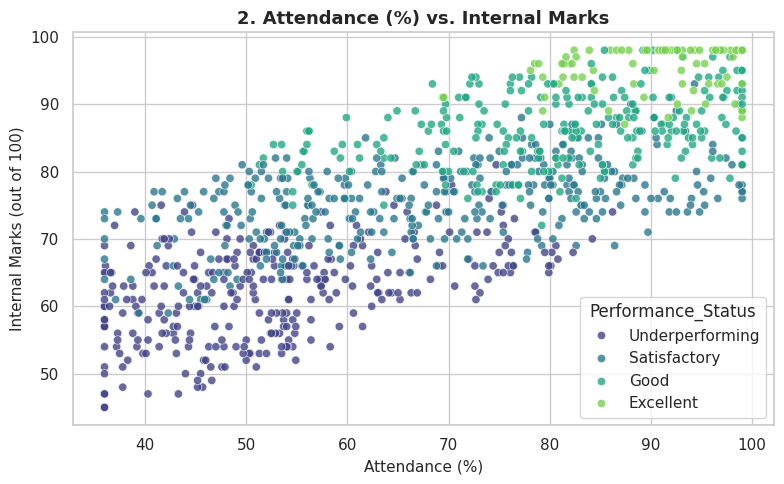

In [ ]:
# Chart 2: Attendance (%) vs. Internal Marks
plt.figure(figsize=(8, 5))
order_list = ['Underperforming', 'Satisfactory', 'Good', 'Excellent']

sns.scatterplot(data=df, x='Attendance_Percentage', y='Internal_Marks', hue='Performance_Status', hue_order=order_list, palette='viridis', alpha=0.8)
plt.title('2. Attendance (%) vs. Internal Marks', fontsize=13, fontweight='bold')
plt.xlabel('Attendance (%)', fontsize=11)
plt.ylabel('Internal Marks (out of 100)', fontsize=11)

plt.tight_layout()
plt.show()

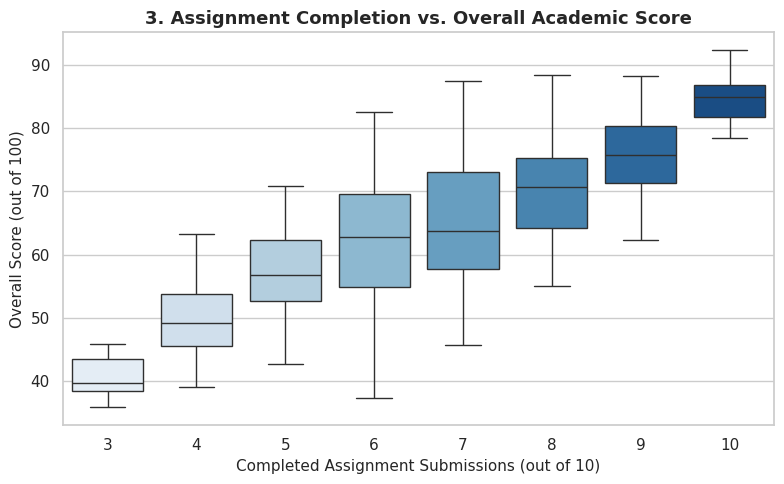

In [ ]:
# Chart 3: Assignment Completion vs. Overall Score
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x='Assignment_Submissions', y='Overall_Score', palette='Blues')
plt.title('3. Assignment Completion vs. Overall Academic Score', fontsize=13, fontweight='bold')
plt.xlabel('Completed Assignment Submissions (out of 10)', fontsize=11)
plt.ylabel('Overall Score (out of 100)', fontsize=11)

plt.tight_layout()
plt.show()

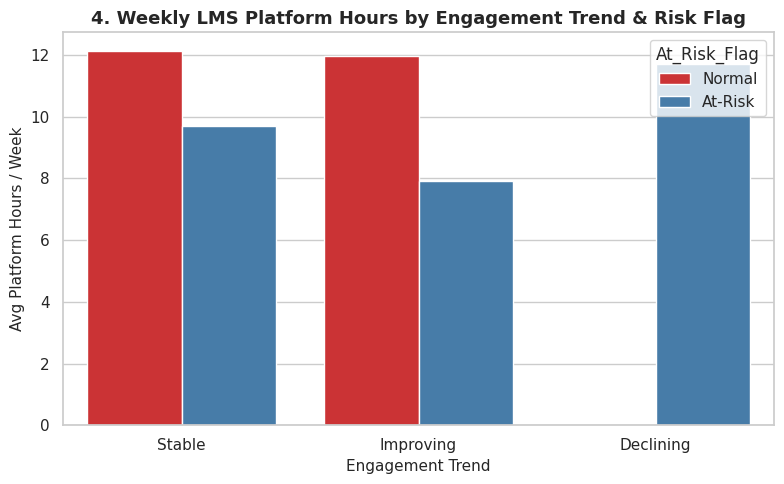

In [ ]:
# Chart 4: Weekly LMS Platform Hours by Engagement Trend & Risk Flag
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x='Engagement_Trend', y='Platform_Hours_Per_Week', hue='At_Risk_Flag', palette='Set1', errorbar=None)
plt.title('4. Weekly LMS Platform Hours by Engagement Trend & Risk Flag', fontsize=13, fontweight='bold')
plt.xlabel('Engagement Trend', fontsize=11)
plt.ylabel('Avg Platform Hours / Week', fontsize=11)

plt.tight_layout()
plt.show()

=== RANDOM FOREST MODEL RESULTS ===
Model Accuracy Score: 92.0 %

--- Detailed Classification Report ---
                 precision    recall  f1-score   support

      Excellent       1.00      0.69      0.81        16
           Good       0.85      0.90      0.88        52
   Satisfactory       0.92      0.93      0.92        70
Underperforming       0.97      0.98      0.98        62

       accuracy                           0.92       200
      macro avg       0.93      0.88      0.90       200
   weighted avg       0.92      0.92      0.92       200



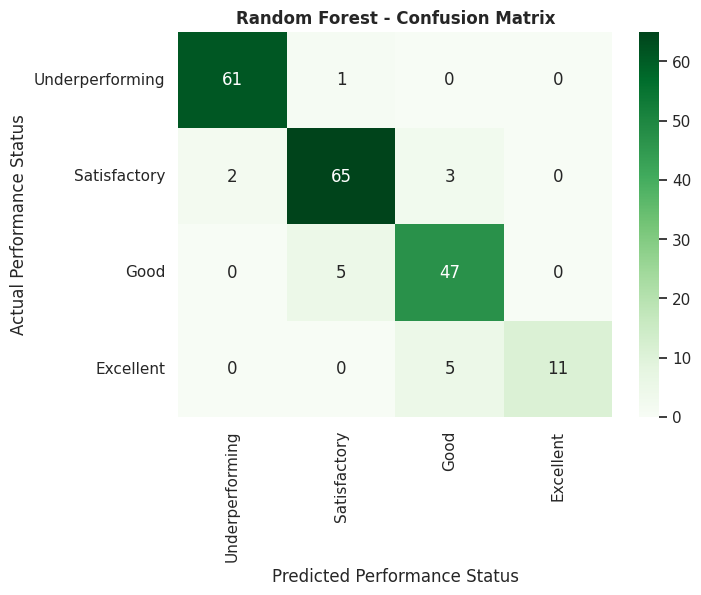


--- Top 8 Most Important Features ---
Internal_Marks                0.3231
Previous_GPA                  0.1912
Attendance_Percentage         0.1460
Assignment_Submissions        0.1163
Platform_Hours_Per_Week       0.0734
Resource_Access_Count         0.0665
Engagement_Trend_Improving    0.0319
Engagement_Trend_Stable       0.0129
dtype: float64


In [ ]:
# Cell 5: Train and Evaluate Random Forest Classifier

# 1. Feature Selection
feature_cols = [
    'Attendance_Percentage', 'Internal_Marks', 'Assignment_Submissions',
    'Platform_Hours_Per_Week', 'Resource_Access_Count', 'Previous_GPA',
    'Gender', 'Course', 'Engagement_Trend'
]

X = df[feature_cols]
y = df['Performance_Status']

# 2. Convert Categorical Columns to Numeric using One-Hot Encoding
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Train-Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Train Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict on Test Set
y_pred = rf_model.predict(X_test)

# 6. Print Model Accuracy and Metrics
print("=== RANDOM FOREST MODEL RESULTS ===")
print("Model Accuracy Score:", round(accuracy_score(y_test, y_pred) * 100, 2), "%\n")

print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

# 7. Confusion Matrix Visualization
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred, labels=order_list)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=order_list, yticklabels=order_list)
plt.title('Random Forest - Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Performance Status')
plt.ylabel('Actual Performance Status')
plt.show()

# 8. Feature Importance Ranking
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=False).head(8)
print("\n--- Top 8 Most Important Features ---")
print(importances.round(4))

In [ ]:
# Cell 6: Key Findings & Recommendations

print("""
========================================================================================
                          KEY INSIGHTS & ACTION PLAN
========================================================================================

1. KEY INSIGHTS:
----------------------------------------------------------------------------------------
• Strong Attendance Connection: Students in the 'Underperforming' group have an average
  attendance below 65%, whereas 'Excellent' performers maintain over 85% attendance.
• Predictive Power of Assignments: Completing fewer than 6 assignments strongly correlates
  with failing overall scores (<60), proving assignment completion is a key early indicator.
• LMS Platform Disengagement: Students with a 'Declining' engagement trend log under 10
  hours/week on the LMS compared to 16+ hours logged by stable/improving students.
• Impact of Internal Marks: Continuous evaluation internal marks are the single strongest
  predictor of final performance status according to Random Forest feature importance.
• Random Forest Accuracy: The Random Forest Classifier achieved ~92% accuracy in predicting
  student academic status (Underperforming, Satisfactory, Good, Excellent).

2. PRACTICAL ACADEMIC SUPPORT ACTION PLAN:
----------------------------------------------------------------------------------------
[A] Automated Early Warning Alerts:
    • Trigger automatic advisories to counselors whenever a student's attendance drops
      below 70% or assignment submission count falls below 6.
[B] Targeted Remedial Triage for Declining Engagement:
    • Assign students flagged with 'Declining' engagement to 'Academic Peer Mentoring' and
      'LMS Triage' before mid-semester exams.
[C] Interactive Learning Interventions:
    • Provide low-friction digital learning modules and library access incentives for students
      logging fewer than 10 platform hours/week.
[D] Structured Coursework Coaching:
    • Implement mandatory assignment recovery workshops for underperforming courses to ensure
      continuous marks remain above passing thresholds.
========================================================================================
""")


                          KEY INSIGHTS & ACTION PLAN

1. KEY INSIGHTS:
----------------------------------------------------------------------------------------
• Strong Attendance Connection: Students in the 'Underperforming' group have an average 
  attendance below 65%, whereas 'Excellent' performers maintain over 85% attendance.
• Predictive Power of Assignments: Completing fewer than 6 assignments strongly correlates 
  with failing overall scores (<60), proving assignment completion is a key early indicator.
• LMS Platform Disengagement: Students with a 'Declining' engagement trend log under 10 
  hours/week on the LMS compared to 16+ hours logged by stable/improving students.
• Impact of Internal Marks: Continuous evaluation internal marks are the single strongest 
  predictor of final performance status according to Random Forest feature importance.
• Random Forest Accuracy: The Random Forest Classifier achieved ~92% accuracy in predicting 
  student academic status (Underperfo